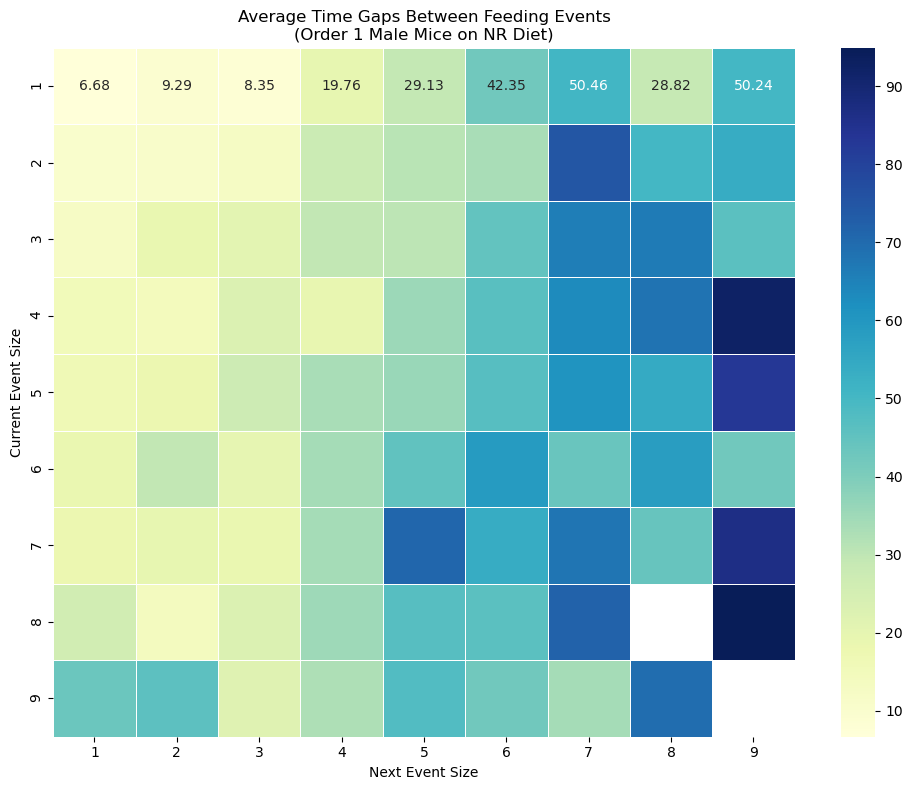


Sample of the processed data:
  Mouse ID  Order Sex Diet Phase  Current Size  Next Size  Time Gap (min)
0  FEDXA01    2.0   M      GRAIN             5          3        4.366667
1  FEDXA01    2.0   M      GRAIN             3          1        2.516667
2  FEDXA01    2.0   M      GRAIN             1          3        4.550000
3  FEDXA01    2.0   M      GRAIN             3          4        6.333333
4  FEDXA01    2.0   M      GRAIN             4          2        2.416667


In [1]:
# Import necessary libraries
import csv
from datetime import datetime
import numpy as np
import trompy as tp  # Ensure 'trompy' is installed and accessible
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to read pellet events from data files
def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        with open(filename, 'r') as file:
            csvreader = csv.reader(file)
            header = next(csvreader)  # Skip header
            rows = [row for row in csvreader if row]
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []
    
    # Determine which format should be used
    date_format = None
    for fmt in formats:
        try:
            datetime.strptime(rows[0][0], fmt)
            date_format = fmt
            break
        except ValueError:
            continue
    if not date_format:
        print(f"Date format not recognized in file: {filename}")
        return []
    
    timestamps = []
    for row in rows: 
        if len(row) > 7 and row[7].strip().lower() == eventname.lower():  # Check event column
            try:
                date_time_obj = datetime.strptime(row[0].strip(), date_format)
                timestamps.append(date_time_obj)
            except ValueError:
                print(f"Invalid date format in row: {row}")
                continue
    
    if len(timestamps) == 0:
        print(f"No '{eventname}' events found in file: {filename}")
        return []
    
    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    try:
        refpoint = datetime.strptime(lightson, date_format)
    except ValueError:
        print(f"Invalid reference point format in file: {filename}")
        return []
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltat_in_min = Deltatinseconds / 60  # Convert to minutes
        pellettimes.append(Deltat_in_min)
    
    return pellettimes

def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in list(output_dictionary.keys()):
            if output_dictionary[mouse_id].get(key) != value:
                output_dictionary.pop(mouse_id)
    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors, verbose=False)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            for key in reduced_dictionary.keys():
                try:
                    output_sublist.append(reduced_dictionary[key][field])
                except KeyError:
                    print("{} is not a key in selected dictionary".format(field))
                    return []
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")
        return []
    
    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list

# Function to cluster pellets into feeding events with timestamps and sizes
def cluster_pellets_by_ipi_with_timestamps(pellettimes, ipi_threshold=1):
    """
    Clusters pellet events based on inter-pellet interval (IPI) in minutes.

    Parameters:
    - pellettimes (list): List of time differences in minutes since reference point.
    - ipi_threshold (int): IPI threshold in minutes to define event boundaries.

    Returns:
    - List of feeding events with 'start_time' and 'size'.
    """
    pellettimes = np.array(sorted(pellettimes))  # Already in minutes
    
    if len(pellettimes) == 0:
        return []
    
    IPIs = np.diff(pellettimes)  # Calculate time differences between consecutive pellets in minutes
    
    # Initialize clusters
    feeding_events = []
    current_cluster = [pellettimes[0]]  # Start with the first pellet
    
    for i, ipi in enumerate(IPIs):
        if ipi <= ipi_threshold:
            current_cluster.append(pellettimes[i + 1])
        else:
            # Record the feeding event
            event = {
                'start_time': current_cluster[0],
                'size': len(current_cluster)
            }
            feeding_events.append(event)
            current_cluster = [pellettimes[i + 1]]
    
    # Add the last event
    if current_cluster:
        event = {
            'start_time': current_cluster[0],
            'size': len(current_cluster)
        }
        feeding_events.append(event)
    
    return feeding_events

# Function to calculate time gaps between feeding events
def calculate_time_gaps_between_events(feeding_events):
    """
    Calculates time intervals between consecutive feeding events.

    Parameters:
    - feeding_events (list): List of feeding events with 'start_time' and 'size'.

    Returns:
    - List of tuples: (current_size, next_size, time_gap_in_minutes)
    """
    time_gaps = []
    
    for i in range(len(feeding_events) - 1):
        current_event = feeding_events[i]
        next_event = feeding_events[i + 1]
        
        current_size = current_event['size']
        next_size = next_event['size']
        time_gap = next_event['start_time'] - current_event['start_time']  # in minutes
        
        time_gaps.append((current_size, next_size, time_gap))
    
    return time_gaps

# Function to aggregate time gaps across mice
def aggregate_time_gaps_across_mice(time_gaps_list):
    """
    Aggregates time gaps from all mice.

    Parameters:
    - time_gaps_list (list): List containing time gaps from each mouse.

    Returns:
    - Dictionary with keys as (current_size, next_size) and values as list of time gaps in minutes.
    """
    aggregated_gaps = {}
    
    for time_gaps in time_gaps_list:
        for current_size, next_size, time_gap in time_gaps:
            key = (current_size, next_size)
            if key not in aggregated_gaps:
                aggregated_gaps[key] = []
            aggregated_gaps[key].append(time_gap)
    
    return aggregated_gaps

# Function to compute average time gaps
def compute_average_time_gaps(aggregated_gaps):
    """
    Computes average time gaps for each (current_size, next_size) pair.

    Parameters:
    - aggregated_gaps (dict): Dictionary with keys as (current_size, next_size) and values as list of time gaps.

    Returns:
    - Dictionary with keys as (current_size, next_size) and values as average time gaps in minutes.
    """
    average_gaps = {}
    for key, intervals in aggregated_gaps.items():
        average_gaps[key] = np.mean(intervals)  # Average in minutes
    return average_gaps

# Function to save the data to CSV
def save_data(df, output_csv):
    """
    Saves the DataFrame to a CSV file.

    Parameters:
    - df (DataFrame): pandas DataFrame to save.
    - output_csv (str): Path to the output CSV file.
    """
    df.to_csv(output_csv, index=False)
    print(f"Data saved to {output_csv}")

# Function to plot heatmap
def plot_heatmap(df_filtered):
    """
    Plots a heatmap of average time gaps between feeding events.

    Parameters:
    - df_filtered (DataFrame): Filtered pandas DataFrame containing relevant data.
    """
    # Group by Current Size and Next Size and calculate the mean Time Gap
    pivot_table = df_filtered.pivot_table(
        index='Current Size',
        columns='Next Size',
        values='Time Gap (min)',
        aggfunc='mean'
    )
    
    # Sort the index and columns for better visualization
    pivot_table = pivot_table.sort_index().sort_index(axis=1)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=.5)
    plt.title('Average Time Gaps Between Feeding Events\n(Order 1 Male Mice on NR Diet)')
    plt.ylabel('Current Event Size')
    plt.xlabel('Next Event Size')
    plt.tight_layout()
    plt.show()

# Main execution
if __name__ == "__main__":
    # Define paths
    metafile = "..\\FEDProtein_METAFILE.xls"  # Update the path if necessary
    data_directory = "..\\data"  # Update the path if necessary

    # Load and process data
    rows, header = tp.metafilereader(metafile, sheetname="METAFILE")
    
    mice = {}
    for row in rows:
        mouse_id = row[1]
        if mouse_id not in mice:
            mice[mouse_id] = {}
            mice[mouse_id]["sex"] = row[4]
            mice[mouse_id]["order"] = row[5]
        # Read pellet times
        if row[1] == mouse_id and row[3].strip().upper() == "FF":
            filename = "..\\data\\{}".format(row[0])  # Update the path if necessary
            diet_phase = row[2].strip().upper()
            if diet_phase in ["GRAIN", "PR", "NR"]:
                pellettimes = get_FEDevents(filename, "Pellet")
                mice[mouse_id][f"{diet_phase.lower()}_timestamps"] = pellettimes

    # Remove mice without any timestamps
    mice = {k: v for k, v in mice.items() if any(
        key in v and v[key] for key in ["grain_timestamps", "pr_timestamps", "nr_timestamps"]
    )}
    
    # Initialize a list to hold time gaps from all mice
    all_time_gaps = []
    
    # Initialize a list to hold all records for saving
    records = []
    
    # Process each mouse
    for mouse_id, attributes in mice.items():
        for diet_phase in ["grain_timestamps", "pr_timestamps", "nr_timestamps"]:
            pellettimes = attributes.get(diet_phase, [])
            if not pellettimes:
                continue  # Skip if no timestamps for this phase
            
            # Get the feeding events with timestamps and sizes
            feeding_events = cluster_pellets_by_ipi_with_timestamps(pellettimes, ipi_threshold=1)  # IPI threshold set to 1 minute
            
            # Calculate time gaps between events
            time_gaps = calculate_time_gaps_between_events(feeding_events)
            
            # Store each time gap with categorical information
            for current_size, next_size, time_gap in time_gaps:
                if current_size > 9 or next_size >9:
                    continue  # Exclude event sizes beyond 7 pellets
                records.append({
                    'Mouse ID': mouse_id,
                    'Order': attributes.get("order"),
                    'Sex': attributes.get("sex"),
                    'Diet Phase': diet_phase.replace('_timestamps', '').upper(),
                    'Current Size': current_size,
                    'Next Size': next_size,
                    'Time Gap (min)': time_gap
                })

    # Create DataFrame from records
    df_stats = pd.DataFrame(records)
    
    # # Save the DataFrame to a CSV file
    # output_csv = "..//results//MEAL_DEF_PELLET_GAP_TIME//feeding_time_gaps_categorized.csv"
    # save_data(df_stats, output_csv)
    
    # Filter for Order 1 Male mice on NR diet
    df_filtered = df_stats[
        (df_stats['Order'] == 1) &
        (df_stats['Sex'].str.upper() == 'M') &
        (df_stats['Diet Phase'].str.upper() == 'NR')
    ]
    
    # Check if the filtered DataFrame is empty
    if df_filtered.empty:
        print("No data available for Order 1 Male mice on NR diet.")
    else:
        # Plot the heatmap
        plot_heatmap(df_filtered)
    
    # Optionally, display the first few rows to verify
    print("\nSample of the processed data:")
    print(df_stats.head())


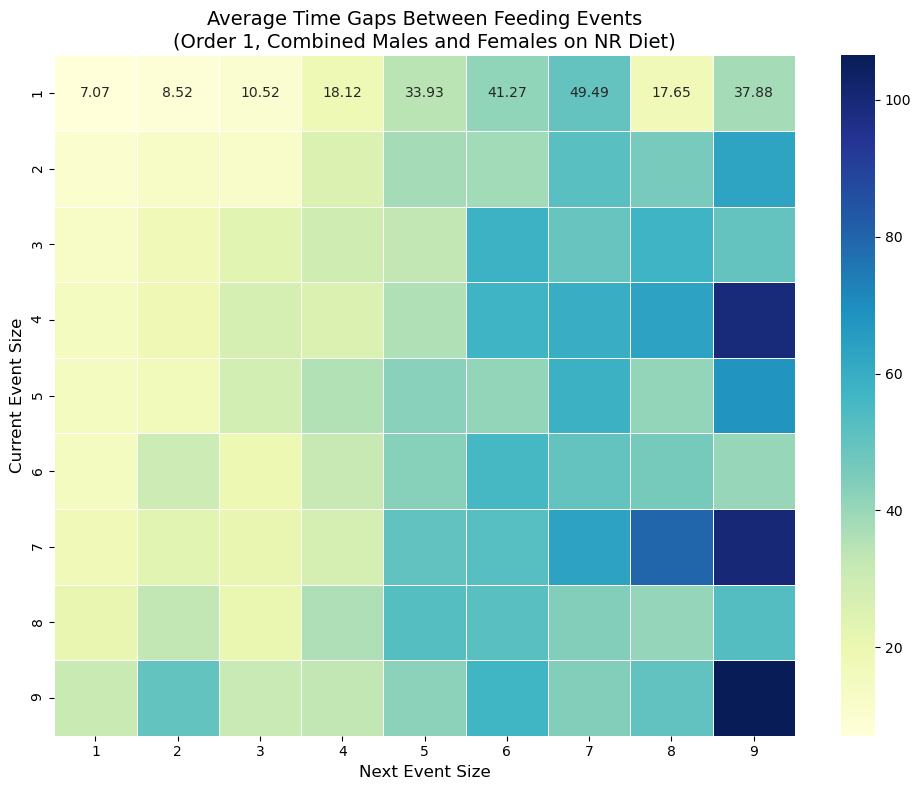

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define your selection criteria here
selected_order = 1        # Select Order 1
selected_diet_phase = 'NR'  # Select Diet Phase 'NR'

# Filter the DataFrame for Order 1, NR phase (combining both sexes)
df_filtered = df_stats[
    (df_stats['Order'] == selected_order) &
    (df_stats['Diet Phase'].str.upper() == selected_diet_phase.upper())
]

# Check if the filtered DataFrame is empty
if df_filtered.empty:
    print(f"No data available for Order {selected_order} on {selected_diet_phase} diet.")
else:
    # Create a pivot table for the heatmap
    pivot_table = df_filtered.pivot_table(
        index='Current Size',
        columns='Next Size',
        values='Time Gap (min)',
        aggfunc='mean'
    )
    
    # Fill any missing values in the pivot table (optional, adjust according to your needs)
    pivot_table = pivot_table.fillna(0)

    # Sort the pivot table for better visualization
    pivot_table = pivot_table.sort_index().sort_index(axis=1)
    
    # Determine the min and max values for color normalization
    vmin = pivot_table.min().min()
    vmax = pivot_table.max().max()
    
    # Plot the heatmap with color normalization and adjusted annotation format
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=.5, vmin=vmin, vmax=vmax, annot_kws={"size": 10})
    plt.title(f'Average Time Gaps Between Feeding Events\n(Order {selected_order}, Combined Males and Females on {selected_diet_phase} Diet)', fontsize=14)
    plt.ylabel('Current Event Size', fontsize=12)
    plt.xlabel('Next Event Size', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()


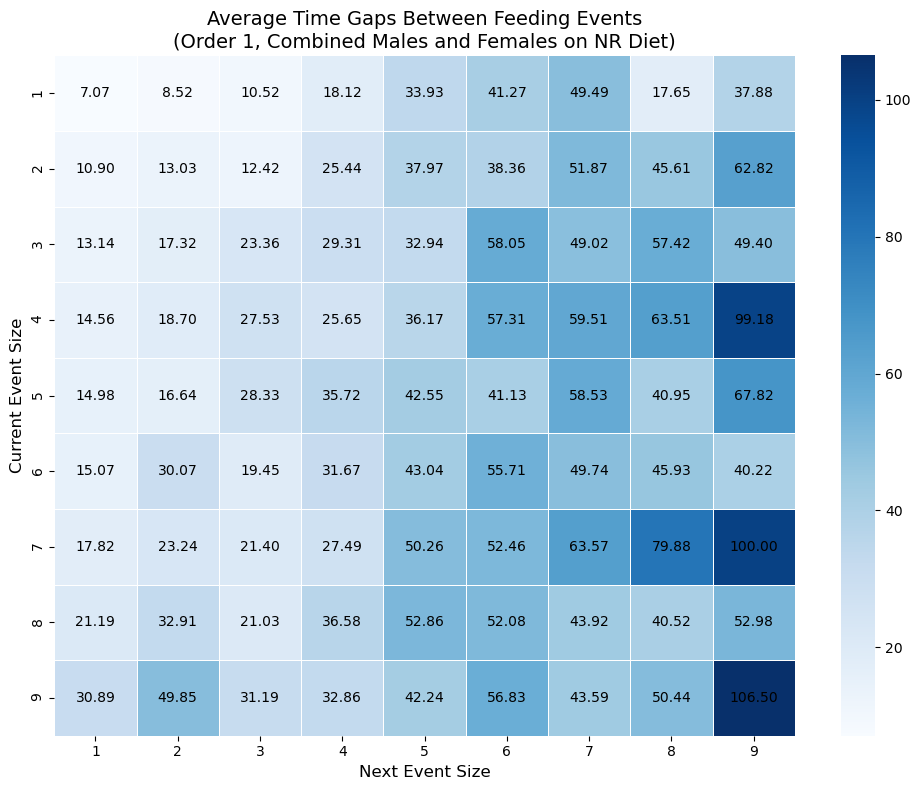

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the heatmap without annotations
plt.figure(figsize=(10, 8))
ax = sns.heatmap(pivot_table, cmap='Blues', linewidths=.5)

# Manually add annotations
for i in range(pivot_table.shape[0]):
    for j in range(pivot_table.shape[1]):
        value = pivot_table.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, f'{value:.2f}', 
                ha='center', va='center', color='black', fontsize=10)

# Add title and labels
plt.title(f'Average Time Gaps Between Feeding Events\n(Order {selected_order}, Combined Males and Females on {selected_diet_phase} Diet)', fontsize=14)
plt.ylabel('Current Event Size', fontsize=12)
plt.xlabel('Next Event Size', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


# Cells below filtering the data to pick particular hours of the day

In [57]:
# Import necessary libraries
import csv
from datetime import datetime
import numpy as np
import trompy as tp  # Ensure 'trompy' is installed and accessible
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to read pellet events from data files
def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']

    try:
        with open(filename, 'r') as file:
            csvreader = csv.reader(file)
            header = next(csvreader)  # Skip header
            rows = [row for row in csvreader if row]
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []

    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    date_format = None
    for fmt in formats:
        try:
            datetime.strptime(rows[0][0], fmt)
            date_format = fmt
            break
        except ValueError:
            continue
    if not date_format:
        print(f"Date format not recognized in file: {filename}")
        return []

    timestamps = []
    for row in rows: 
        if len(row) > 7 and row[7].strip().lower() == eventname.lower():  # Check event column
            try:
                date_time_obj = datetime.strptime(row[0].strip(), date_format)
                timestamps.append(date_time_obj)
            except ValueError:
                print(f"Invalid date format in row: {row}")
                continue

    if len(timestamps) == 0:
        print(f"No '{eventname}' events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    try:
        refpoint = datetime.strptime(lightson, date_format)
    except ValueError:
        print(f"Invalid reference point format in file: {filename}")
        return []

    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltat_in_min = Deltatinseconds / 60  # Convert to minutes
        pellettimes.append(Deltat_in_min)

    return pellettimes

# Function to cluster pellets into feeding events with timestamps and sizes
def cluster_pellets_by_ipi_with_timestamps(pellettimes, ipi_threshold=1):
    """
    Clusters pellet events based on inter-pellet interval (IPI) in minutes.

    Parameters:
    - pellettimes (list): List of time differences in minutes since reference point.
    - ipi_threshold (int): IPI threshold in minutes to define event boundaries.

    Returns:
    - List of feeding events with 'start_time' and 'size'.
    """
    pellettimes = np.array(sorted(pellettimes))  # Already in minutes

    if len(pellettimes) == 0:
        return []

    IPIs = np.diff(pellettimes)  # Calculate time differences between consecutive pellets in minutes

    # Initialize clusters
    feeding_events = []
    current_cluster = [pellettimes[0]]  # Start with the first pellet

    for i, ipi in enumerate(IPIs):
        if ipi <= ipi_threshold:
            current_cluster.append(pellettimes[i + 1])
        else:
            # Record the feeding event
            event = {
                'start_time': current_cluster[0] / 60,  # Convert minutes to hours
                'size': len(current_cluster)
            }
            feeding_events.append(event)
            current_cluster = [pellettimes[i + 1]]

    # Add the last event
    if current_cluster:
        event = {
            'start_time': current_cluster[0] / 60,  # Convert minutes to hours
            'size': len(current_cluster)
        }
        feeding_events.append(event)

    return feeding_events

# Function to calculate time gaps between feeding events
def calculate_time_gaps_between_events(feeding_events):
    """
    Calculates time intervals between consecutive feeding events.

    Parameters:
    - feeding_events (list): List of feeding events with 'start_time' and 'size'.

    Returns:
    - List of tuples: (current_size, next_size, time_gap_in_minutes)
    """
    time_gaps = []

    for i in range(len(feeding_events) - 1):
        current_event = feeding_events[i]
        next_event = feeding_events[i + 1]

        current_size = current_event['size']
        next_size = next_event['size']
        time_gap = next_event['start_time'] - current_event['start_time']  # in hours

        time_gaps.append((current_size, next_size, time_gap))

    return time_gaps

# Main execution
if __name__ == "__main__":
    # Define paths
    metafile = "..\\FEDProtein_METAFILE.xls"  # Update the path if necessary
    data_directory = "..\\data"  # Update the path if necessary

    # Load and process data
    rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

    mice = {}
    for row in rows:
        mouse_id = row[1]
        if mouse_id not in mice:
            mice[mouse_id] = {}
            mice[mouse_id]["sex"] = row[4]
            mice[mouse_id]["order"] = row[5]
        # Read pellet times
        if row[1] == mouse_id and row[3].strip().upper() == "FF":
            filename = "..\\data\\{}".format(row[0])  # Update the path if necessary
            diet_phase = row[2].strip().upper()
            if diet_phase in ["GRAIN", "PR", "NR"]:
                pellettimes = get_FEDevents(filename, "Pellet")
                mice[mouse_id][f"{diet_phase.lower()}_timestamps"] = pellettimes

    # Remove mice without any timestamps
    mice = {k: v for k, v in mice.items() if any(
        key in v and v[key] for key in ["grain_timestamps", "pr_timestamps", "nr_timestamps"]
    )}

    # Initialize a list to hold all records for saving
    records = []

    # Process each mouse
    for mouse_id, attributes in mice.items():
        for diet_phase in ["grain_timestamps", "pr_timestamps", "nr_timestamps"]:
            pellettimes = attributes.get(diet_phase, [])
            if not pellettimes:
                continue  # Skip if no timestamps for this phase

            # Get the feeding events with timestamps and sizes
            feeding_events = cluster_pellets_by_ipi_with_timestamps(pellettimes, ipi_threshold=1)

            # Filter feeding events for hours 12–16
            peak_hour_events = [
                event for event in feeding_events
                if 18 <= event['start_time'] < 23
            ]

            # Calculate time gaps between events
            time_gaps = calculate_time_gaps_between_events(peak_hour_events)

            # Store each time gap with categorical information
            for current_size, next_size, time_gap in time_gaps:
                if current_size > 10 or next_size > 10:
                    continue  # Exclude event sizes beyond 9 pellets
                records.append({
                    'Mouse ID': mouse_id,
                    'Order': attributes.get("order"),
                    'Sex': attributes.get("sex"),
                    'Diet Phase': diet_phase.replace('_timestamps', '').upper(),
                    'Current Size': current_size,
                    'Next Size': next_size,
                    'Time Gap (hours)': time_gap
                })

    # Create DataFrame from records
    df_stats = pd.DataFrame(records)

    # Optionally, display the first few rows to verify
    print("\nSample of the processed data:")
    print(df_stats.head())



Sample of the processed data:
  Mouse ID  Order Sex Diet Phase  Current Size  Next Size  Time Gap (hours)
0  FEDXA01    2.0   M      GRAIN             1          7          0.078889
1  FEDXA01    2.0   M      GRAIN             7          3          0.044167
2  FEDXA01    2.0   M      GRAIN             3          3          0.140000
3  FEDXA01    2.0   M      GRAIN             3          4          0.050000
4  FEDXA01    2.0   M      GRAIN             4          4          0.207778


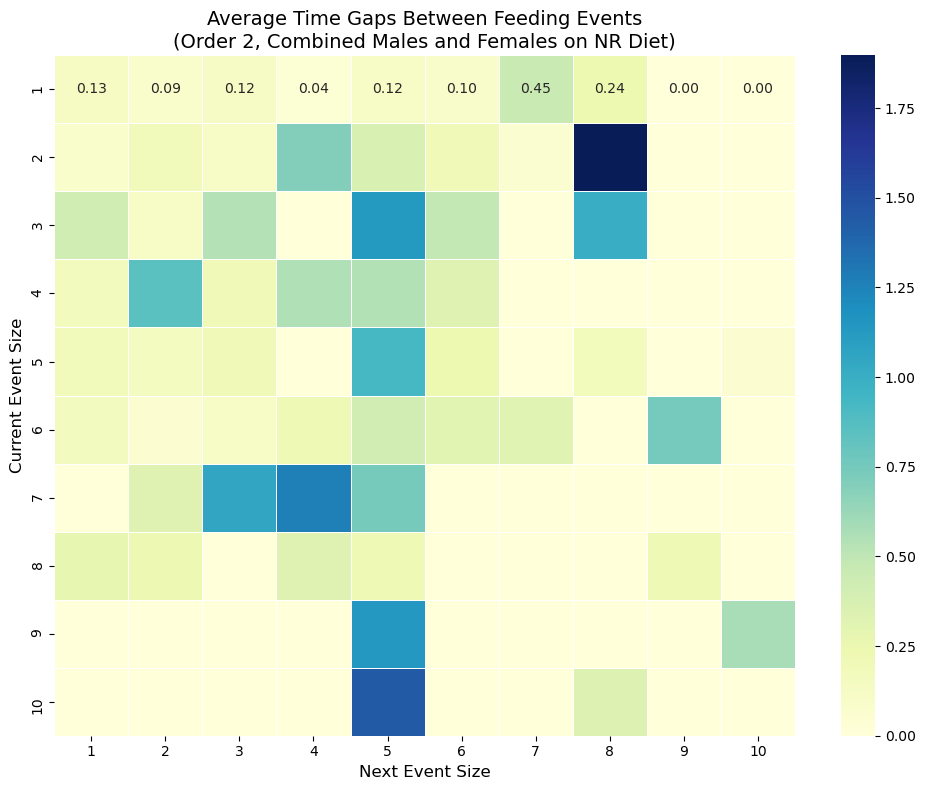

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define your selection criteria here
selected_order = 2        # Select Order 1
selected_diet_phase = 'NR'  # Select Diet Phase 'NR'

# Filter the DataFrame for Order 1, NR phase (combining both sexes)
df_filtered = df_stats[
    (df_stats['Order'] == selected_order) &
    (df_stats['Diet Phase'].str.upper() == selected_diet_phase.upper())
]

# Check if the filtered DataFrame is empty
if df_filtered.empty:
    print(f"No data available for Order {selected_order} on {selected_diet_phase} diet.")
else:
    # Create a pivot table for the heatmap
    pivot_table = df_filtered.pivot_table(
        index='Current Size',
        columns='Next Size',
        values='Time Gap (hours)',  # Updated column name
        aggfunc='mean'
    )
    
    # Fill any missing values in the pivot table (optional, adjust according to your needs)
    pivot_table = pivot_table.fillna(0)

    # Sort the pivot table for better visualization
    pivot_table = pivot_table.sort_index().sort_index(axis=1)
    
    # Determine the min and max values for color normalization
    vmin = pivot_table.min().min()
    vmax = pivot_table.max().max()
    
    # Plot the heatmap with color normalization and adjusted annotation format
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap='YlGnBu', linewidths=.5, vmin=vmin, vmax=vmax, annot_kws={"size": 10})
    plt.title(f'Average Time Gaps Between Feeding Events\n(Order {selected_order}, Combined Males and Females on {selected_diet_phase} Diet)', fontsize=14)
    plt.ylabel('Current Event Size', fontsize=12)
    plt.xlabel('Next Event Size', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()


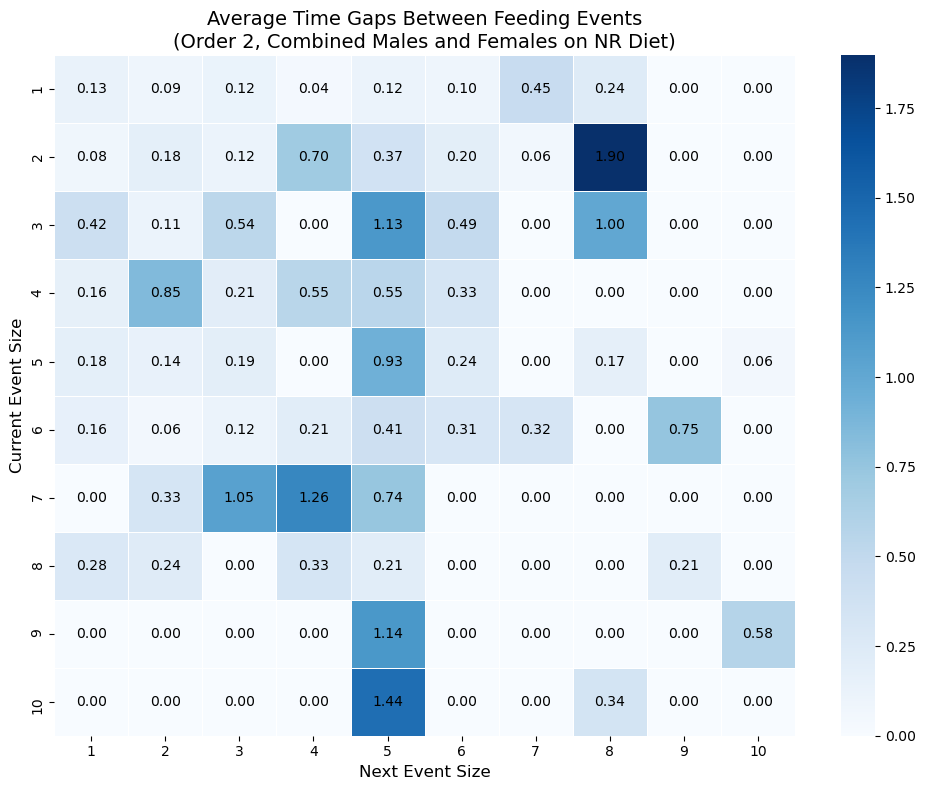

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the heatmap without annotations
plt.figure(figsize=(10, 8))
ax = sns.heatmap(pivot_table, cmap='Blues', linewidths=.5)

# Manually add annotations
for i in range(pivot_table.shape[0]):
    for j in range(pivot_table.shape[1]):
        value = pivot_table.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, f'{value:.2f}', 
                ha='center', va='center', color='black', fontsize=10)

# Add title and labels
plt.title(f'Average Time Gaps Between Feeding Events\n(Order {selected_order}, Combined Males and Females on {selected_diet_phase} Diet)', fontsize=14)
plt.ylabel('Current Event Size', fontsize=12)
plt.xlabel('Next Event Size', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


C:\Users\hta031\AppData\Local\Temp\ipykernel_91536\605874934.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Time Gap (min)'] = df_filtered['Time Gap (hours)'] * 60
c:\Users\hta031\AppData\Local\miniconda3\envs\DATA\Lib\site-packages\seaborn\matrix.py:262: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


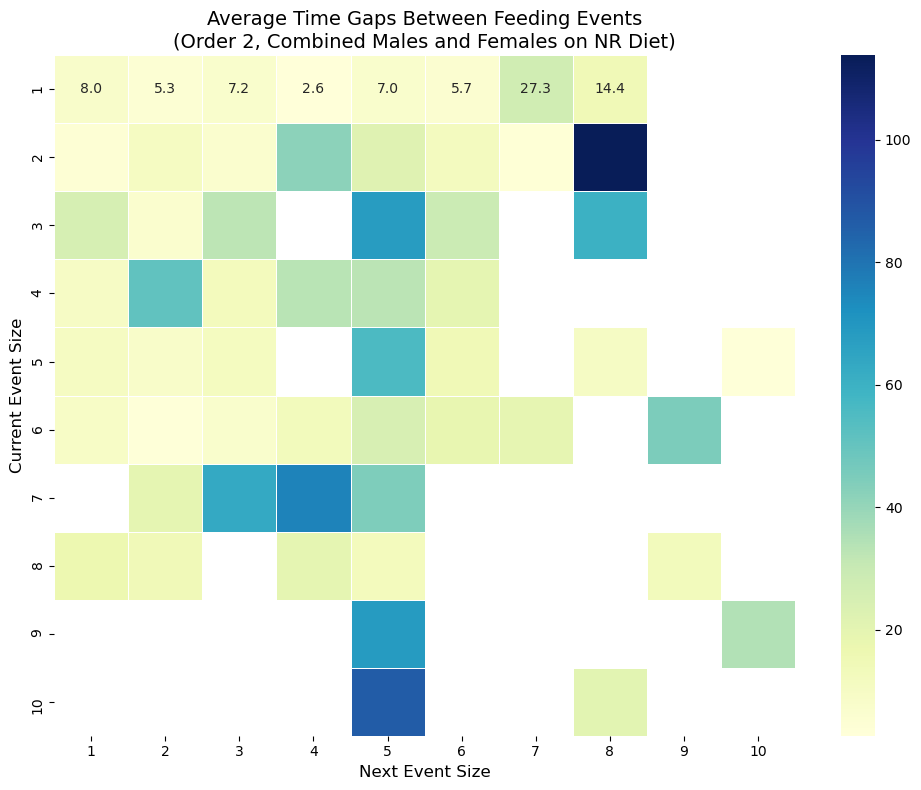

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define your selection criteria here
selected_order = 2       # Select Order 1
selected_diet_phase = 'NR'  # Select Diet Phase 'NR'

# Filter the DataFrame for Order 1, NR phase (combining both sexes)
df_filtered = df_stats[
    (df_stats['Order'] == selected_order) &
    (df_stats['Diet Phase'].str.upper() == selected_diet_phase.upper())
]

# Convert 'Time Gap (hours)' to 'Time Gap (min)' for visualization
df_filtered['Time Gap (min)'] = df_filtered['Time Gap (hours)'] * 60

# Check if the filtered DataFrame is empty
if df_filtered.empty:
    print(f"No data available for Order {selected_order} on {selected_diet_phase} diet.")
else:
    # Create a pivot table for the heatmap
    pivot_table = df_filtered.pivot_table(
        index='Current Size',
        columns='Next Size',
        values='Time Gap (min)',  # Use converted values in minutes
        aggfunc='mean'
    )
    
    # Optionally fill missing values
    # pivot_table = pivot_table.fillna(0)  # Uncomment if you want to fill NaN with 0

    # Sort the pivot table for better visualization
    pivot_table = pivot_table.sort_index().sort_index(axis=1)
    
    # Determine the min and max values for color normalization
    vmin = pivot_table.min().min()
    vmax = pivot_table.max().max()
    
    # Plot the heatmap with color normalization and adjusted annotation format
    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='YlGnBu', linewidths=.5, vmin=vmin, vmax=vmax, annot_kws={"size": 10})
    plt.title(f'Average Time Gaps Between Feeding Events\n(Order {selected_order}, Combined Males and Females on {selected_diet_phase} Diet)', fontsize=14)
    plt.ylabel('Current Event Size', fontsize=12)
    plt.xlabel('Next Event Size', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()


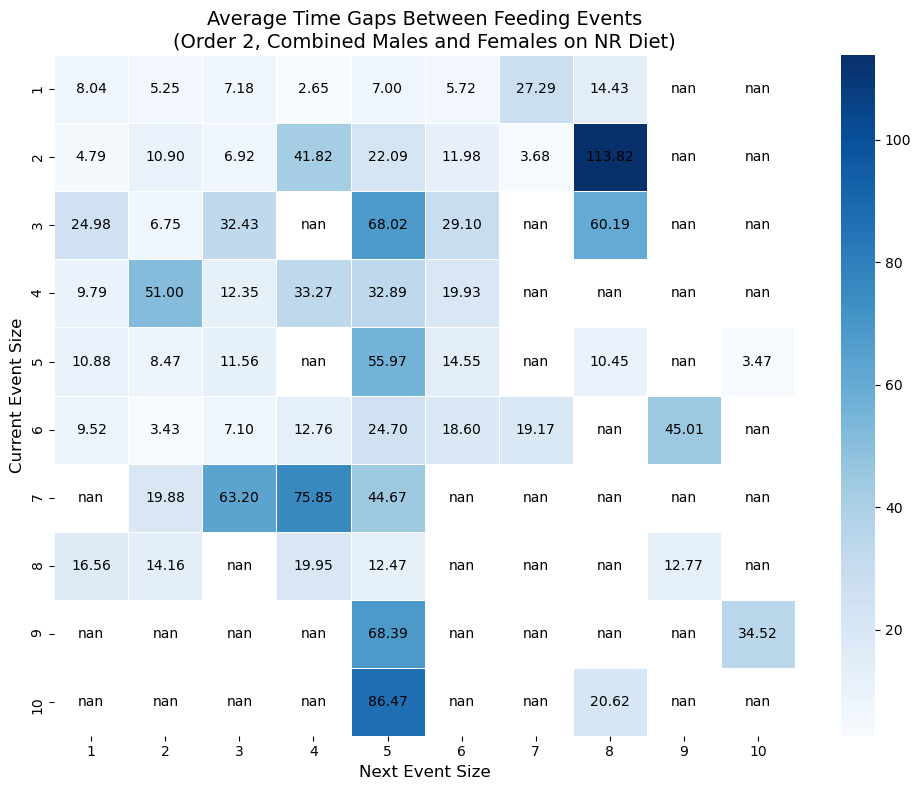

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the heatmap without annotations
plt.figure(figsize=(10, 8))
ax = sns.heatmap(pivot_table, cmap='Blues', linewidths=.5)

# Manually add annotations
for i in range(pivot_table.shape[0]):
    for j in range(pivot_table.shape[1]):
        value = pivot_table.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, f'{value:.2f}', 
                ha='center', va='center', color='black', fontsize=10)

# Add title and labels
plt.title(f'Average Time Gaps Between Feeding Events\n(Order {selected_order}, Combined Males and Females on {selected_diet_phase} Diet)', fontsize=14)
plt.ylabel('Current Event Size', fontsize=12)
plt.xlabel('Next Event Size', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()
